In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import logging
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from xgboost import plot_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

In [2]:
od = pd.read_csv("Order.csv",encoding='latin-1')
rt = pd.read_csv("Return.csv", encoding ='latin-1')
pp = pd.read_csv("People.csv", encoding='latin-1')

In [3]:
od.shape

(51290, 24)

In [4]:
rt.shape

(1079, 3)

In [5]:
pp.shape

(24, 2)

In [6]:
od.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   Postal Code     9994 non-null   float64
 9   City            51290 non-null  str    
 10  State           51290 non-null  str    
 11  Country         51290 non-null  str    
 12  Region          51290 non-null  str    
 13  Market          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [7]:
od.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,$221.98,2,0.0,$62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","$3,709.40",9,0.1,($288.77),923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID","$5,175.17",9,0.1,$919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless","$2,892.51",5,0.1,($96.54),910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed","$2,832.96",8,0.0,$311.52,903.04,Critical
5,22732,IN-2014-JM156557-41818,6/28/2014,7/1/2014,Second Class,JM-156557,Jim Mitchum,Corporate,NaN,Sydney,...,TEC-PH-5842,Technology,Phones,"Samsung Smart Phone, with Caller ID","$2,862.68",5,0.1,$763.28,897.35,Critical
6,30570,IN-2012-TS2134092-41219,11/6/2012,11/8/2012,First Class,TS-2134092,Toby Swindell,Consumer,NaN,Porirua,...,FUR-CH-5378,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable","$1,822.08",4,0.0,$564.84,894.77,Critical
7,31192,IN-2013-MB1808592-41378,4/14/2013,4/18/2013,Standard Class,MB-1808592,Mick Brown,Consumer,NaN,Hamilton,...,FUR-TA-3764,Furniture,Tables,"Chromcraft Conference Table, Fully Assembled","$5,244.84",6,0.0,$996.48,878.38,High
8,40099,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,FUR-BO-5957,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",$341.96,2,0.0,$54.71,25.27,High
9,36258,CA-2012-AB10015140-40974,3/6/2012,3/7/2012,First Class,AB-100151404,Aaron Bergman,Consumer,98103.0,Seattle,...,FUR-CH-4421,Furniture,Chairs,"Global Push Button Manager's Chair, Indigo",$48.71,1,0.2,$5.48,11.13,High


In [8]:
od.isna().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [9]:
od.duplicated().sum()

np.int64(0)

Làm sạch dữ liệu tiền

In [10]:
def clean_money(col):
    col = col.astype(str)
    col = col.str.replace('$', '', regex=False)
    col = col.str.replace(',', '', regex=False)
    col = col.str.replace('(', '-', regex=False)
    col = col.str.replace(')', '', regex=False)
    col = col.str.strip()
    return pd.to_numeric(col, errors='coerce')

for col in ['Sales', 'Profit', 'Shipping Cost']:
    od[col] = clean_money(od[col])

In [11]:
od1 = od.drop(columns=['Row ID', 'Postal Code'])
columns_to_show = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
od1[columns_to_show].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490685,3.476545,0.142908,28.610970,26.478567
std,487.565388,2.278766,0.212280,174.341066,57.251373
min,0.440000,1.000000,0.000000,-6599.980000,1.002000
25%,30.762500,2.000000,0.000000,0.000000,2.610000
50%,85.055000,3.000000,0.000000,9.240000,7.790000
75%,251.055000,5.000000,0.200000,36.810000,24.450000
max,22638.480000,14.000000,0.850000,8399.980000,933.570000


BẢNG THỐNG KÊ MÔ TẢ


 Quantity:
 - Trung bình 3-4 sản phẩm/đơn
-> Đơn hàng nhỏ lẻ

Discount:
 - Trung bình là ~14% nhưng median = 0 -> Phần lớn đơn hàng không có giảm giá
 - Nhưng max = 85% -> Sẽ có nhưng đơn hàng giảm giá rất cao

Shipping Cost:
 - Trung bình ~26 nhưng median chỉ ~7.8 -> Dữ liệu lệch phải
 - Max = 933 -> Đơn hàng cho chi phí vận chuyển bất thường

In [12]:
od.describe(include=['object', 'string'])

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25728,1430,1464,4,17415,796,3,3650,1102,165,23,5,3788,3,17,3788,4
top,CA-2015-SV20365140-42268,6/18/2015,11/22/2015,Standard Class,SV-203651406,Muhammed Yedwab,Consumer,New York City,California,United States,Western Europe,Asia Pacific,OFF-FA-6129,Office Supplies,Binders,Staples,Medium
freq,14,135,130,30775,26,108,26518,915,2001,9994,5883,14302,227,31289,6146,227,29433


Thống kê doanh thu theo Danh mục hàng hóa

In [13]:
sales_stats = od.groupby('Sub-Category')['Sales'].agg(
    Count='count',
    Mean=('mean'),
    Median='median',
    Min='min',
    Max='max'
)

sales_stats['Mean'] = sales_stats['Mean'].round(3)
sales_stats['Median'] = sales_stats['Median'].round(3)

print("\n--- Thống kê theo Danh mục hàng hóa ---")
print(sales_stats)


--- Thống kê theo Danh mục hàng hóa ---
              Count     Mean   Median    Min       Max
Sub-Category                                          
Accessories    3075  243.654  132.500   0.99   3449.88
Appliances     1742  580.101  251.485   0.44   7958.58
Art            4864   76.401   50.100   1.34   1113.02
Binders        6146   75.150   28.230   0.56   9892.74
Bookcases      2411  608.284  411.330  35.49   5667.87
Chairs         3434  437.298  258.000  13.55   5759.96
Copiers        2223  679.009  487.380  35.46  17499.95
Envelopes      2387   70.891   48.030   1.63    604.66
Fasteners      2601   34.408   25.870   1.24    271.32
Furnishings    3154  122.117   73.720   1.89   1519.14
Labels         2601   28.201   20.650   1.67    786.48
Machines       1486  524.267  305.145  11.51  22638.48
Paper          3492   69.240   43.820   3.38    733.95
Phones         3357  508.437  273.300   2.97   6998.64
Storage        5049  223.176  113.820   2.80   2962.68
Supplies       2407  100

Thống kê doanh thu theo phân khúc

In [14]:
sales_stats = od.groupby('Segment')['Sales'].agg(
    Count='count',
    Mean=('mean'),
    Median='median',
    Min='min',
    Max='max'
)

sales_stats['Mean'] = sales_stats['Mean'].round(3)
sales_stats['Median'] = sales_stats['Median'].round(3)

print("\n--- Thống kê theo phân khúc ---")
print(sales_stats)


--- Thống kê theo phân khúc ---
             Count     Mean  Median   Min       Max
Segment                                            
Consumer     26518  245.416  85.005  0.44  13999.96
Corporate    15429  247.890  85.440  0.56  17499.95
Home Office   9343  247.229  84.600  0.99  22638.48


Biểu đồ histogram của biến Sales.

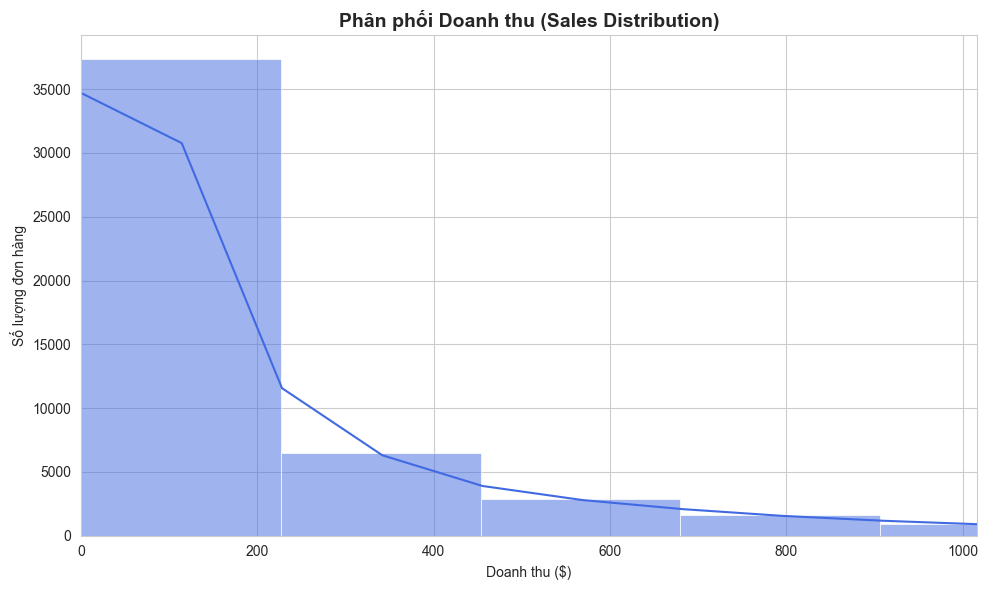

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Sales'], bins=100, kde=True, color='royalblue')
plt.title('Phân phối Doanh thu (Sales Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Doanh thu ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(0, od['Sales'].quantile(0.95))
plt.tight_layout()
plt.savefig('histogram_sales.png', dpi=300)
plt.show()

- Biểu đồ Histogram của Doanh thu cho thấy sự phân bố không đồng đều. Số lượng đơn hàng tập trung nhiều ở phân khúc có giá trị thấp( dưới 200$), trong khi các đơn hàng có giá trị cao có số lượng rất ít kéo dài về phía bên phải.
- Điều này phản ánh mô hình bán lẻ phổ biến: nhiều đơn nhỏ, ít đơn lớn.

Biểu đồ boxplot của biến Sales.

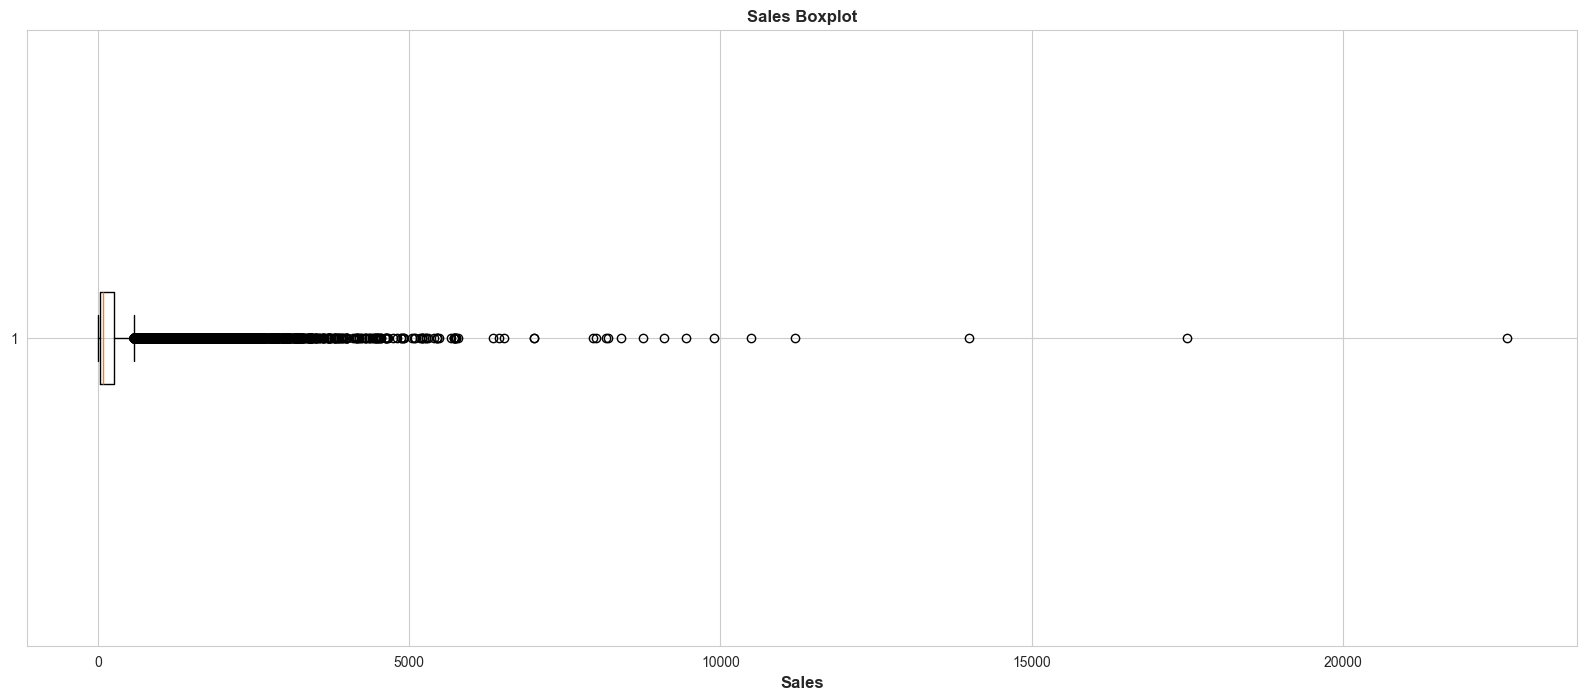

In [16]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Sales'],vert=False)
plt.title('Sales Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Sales', fontsize=12, fontweight='bold')
plt.show()

- Phân phối doanh thu có xu hướng lệch phải, với phần lớn đơn hàng có giá trị thấp.
- Một số ít đơn hàng có giá trị rất cao tạo ra nhiều outlier.
- Độ phân tán(IQR) lớn -> Sales biến động mạnh giữa các đơn hàng

Biểu đồ histogram của biến Profit.

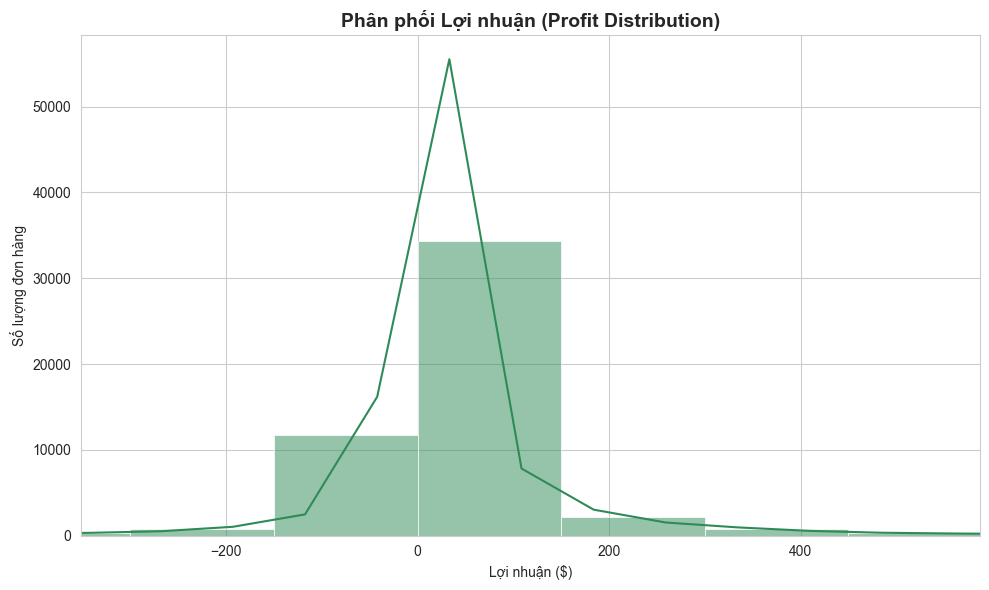

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Profit'], bins=100, kde=True, color='seagreen')
plt.title('Phân phối Lợi nhuận (Profit Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Lợi nhuận ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(od['Profit'].quantile(0.01), od['Profit'].quantile(0.99))
plt.tight_layout()
plt.savefig('histogram_profit.png', dpi=300)
plt.show()

- Dữ liệu phân bố quanh mức gần 0 -> Nhiều đơn hàng không có lãi thậm chí âm. Điều này phản ảnh hiệu qu kinh doanh không đồng đều giữa các đơn hàng, doanh nghiệp cần xem xét lại ngay vì mức lợi nhuận này rất báo động.

Biểu đồ boxplot của biến Profit.

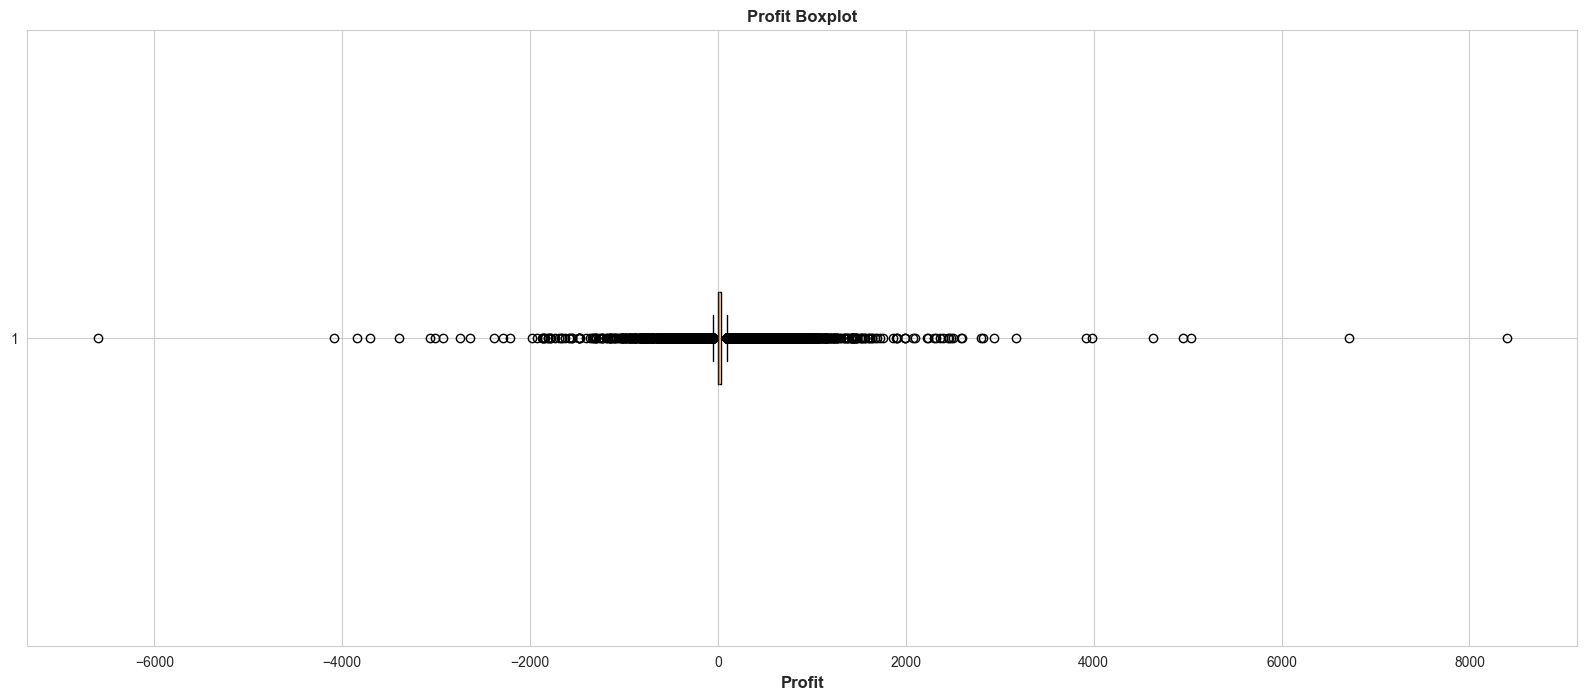

In [18]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Profit'],vert=False)
plt.title('Profit Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Profit', fontsize=12, fontweight='bold')
plt.show()

- Median Profit giữa các nhóm có sự khác biệt rõ rệt.
- Có nhiều outlier âm, đặc biệt ở một số nhóm sản phẩm.
- Một số nhóm có IQR rộng → lợi nhuận biến động mạnh.

Biểu đồ histogram của biến Shipping Cost

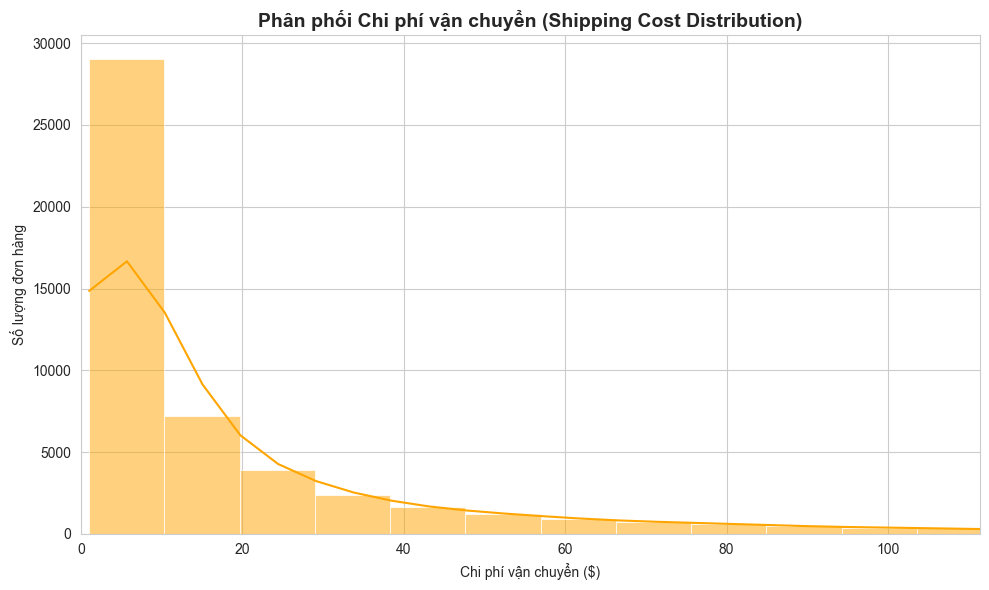

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Shipping Cost'], bins=100, kde=True, color='orange')
plt.title('Phân phối Chi phí vận chuyển (Shipping Cost Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Chi phí vận chuyển ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(0, od['Shipping Cost'].quantile(0.95))
plt.tight_layout()
plt.savefig('histogram_shipping_cost.png', dpi=300)
plt.show()

- Phần lớn đơn hàng có chi phí vận chuyển thấp
- Bên cạnh đó xuất hiện nhiều đơn hàng có giá trị vận chuyển cao, tăng đột biến.

Biểu đồ boxplot của biến Shipping Cost.

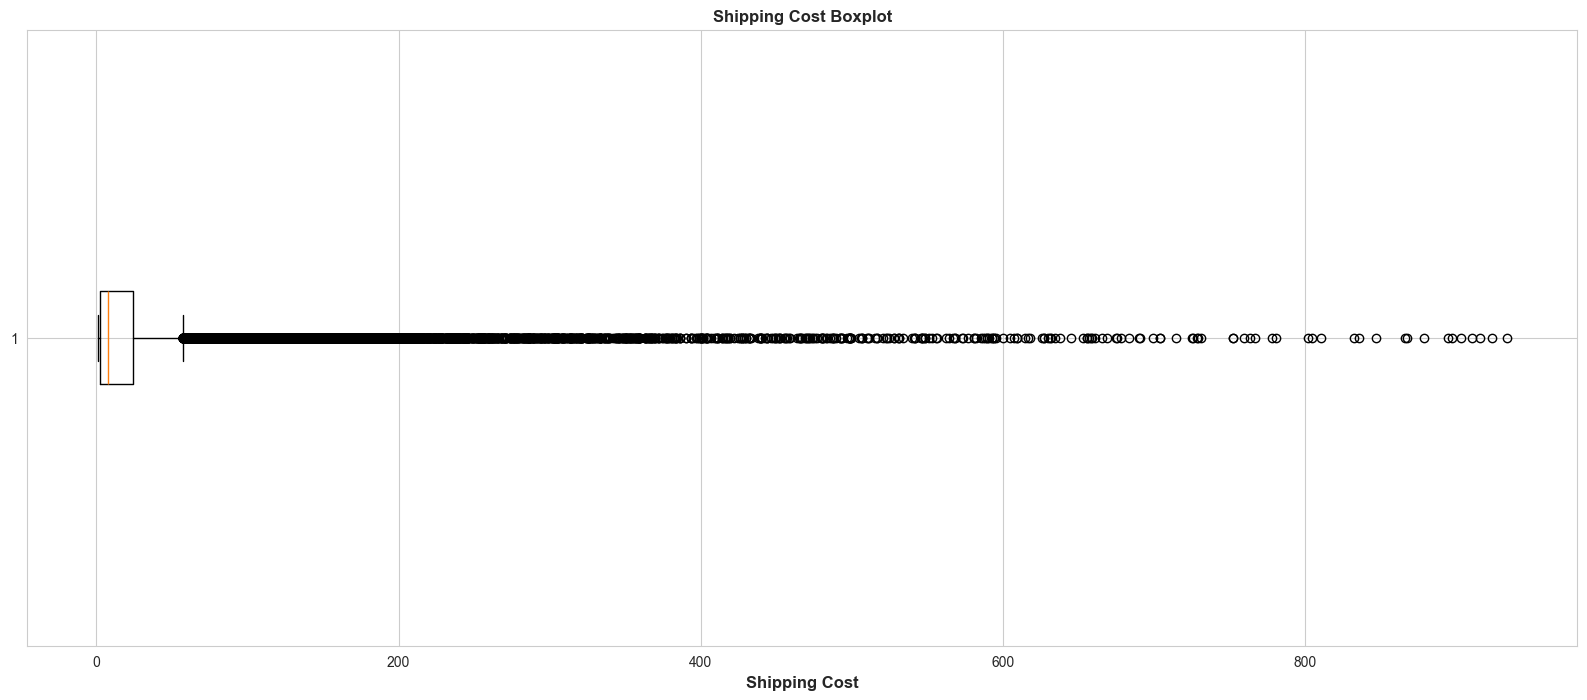

In [20]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Shipping Cost'],vert=False)
plt.title('Shipping Cost Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Shipping Cost', fontsize=12, fontweight='bold')
plt.show()

- Phần lớn đơn hàng có chi phí vận chuyển rất rẻ
- Xuất hiện nhiều outliers -> Nhiều đơn hàng có chi phí vận chuyển đột biến. Điều này có thể rơi vào:
    + Đơn hàng quốc tế
    + Hàng hóa cồng kềnh
    + Giao hàng hỏa tốc

-> Kết hợp với biểu đồ lợi nhuận bên trên thì dải chi phí vận chuyển tăng cao này là nguyên nhân nhiều đơn hàng có lỗ lớn

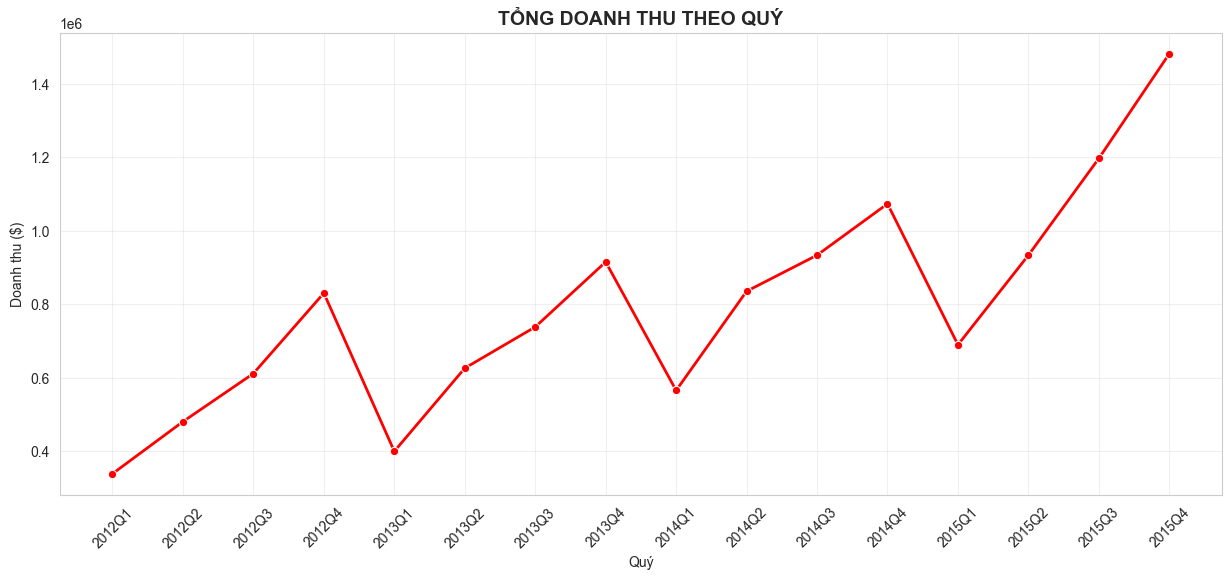

In [21]:
od['Order Date'] = pd.to_datetime(od['Order Date'])
od['Quarter'] = od['Order Date'].dt.to_period('Q').astype(str)
df_quy = od.groupby('Quarter')['Sales'].sum().reset_index()
od['Quarter'] = od['Order Date'].dt.to_period('Q').astype(str)
df_quy = od.groupby('Quarter')['Sales'].sum().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_quy, x='Quarter', y='Sales', marker='o', color='red', linewidth=2)
plt.title('TỔNG DOANH THU THEO QUÝ', fontsize=14, fontweight='bold')
plt.xlabel('Quý')
plt.ylabel('Doanh thu ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

- Tổng doanh thu có sự đi lên rõ rột qua các năm 2012 đến 2015 ( Từ 400k  đến  1.5M )
- Doanh thu luôn sụt giảm mạnh vào quý 1 hằng năm và tăng vọt vào quý 4 ( vì cuối năm thường sẽ có các sự kiến mua sắm lớn như Black Friday, Giáng sinh, Năm mới )

-> BIỂU ĐỒ DOANH THU THEO QUÝ GIAI ĐOẠN 2012 - 2015 CHO THẤY SỰ TĂNG TRƯỞNG TÍCH CỰC VỀ QUY MÔ. HOẠT ĐỘNG KINH DOANH MANG TÍNH MÙA VỤ VỚI ĐỈNH DOANH THU RƠI VÀO CUỐI NĂM. ĐÂY LÀ CƠ SỞ ĐỂ DOANH NGHIỆP LẬP KẾ HOẠCH DỰ TRỮ HÀNG HÓA VÀ CHUẨN BỊ NHÂN SỰ CHO CÁC GIAI ĐOẠN CAO ĐIỂM.

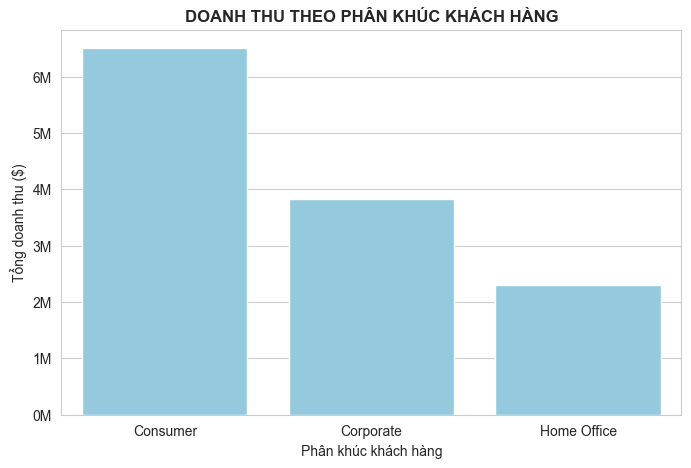

In [22]:
segment_revenue = od.groupby('Segment')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_revenue, x='Segment', y='Sales', color='skyblue')
plt.title('DOANH THU THEO PHÂN KHÚC KHÁCH HÀNG', fontsize=12, fontweight='bold')
plt.xlabel('Phân khúc khách hàng')
plt.ylabel('Tổng doanh thu ($)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6))))
plt.show()

- Consumer đóng góp doanh thu cao nhất ( vượt 6M USD). Điều này cho thấy việc kinh doanh đang tập trung mạnh vào bán lẻ cá nhân tuy nhiên có sự mất cân bằng so với 2 nhóm còn lại là Corporate và Home Office

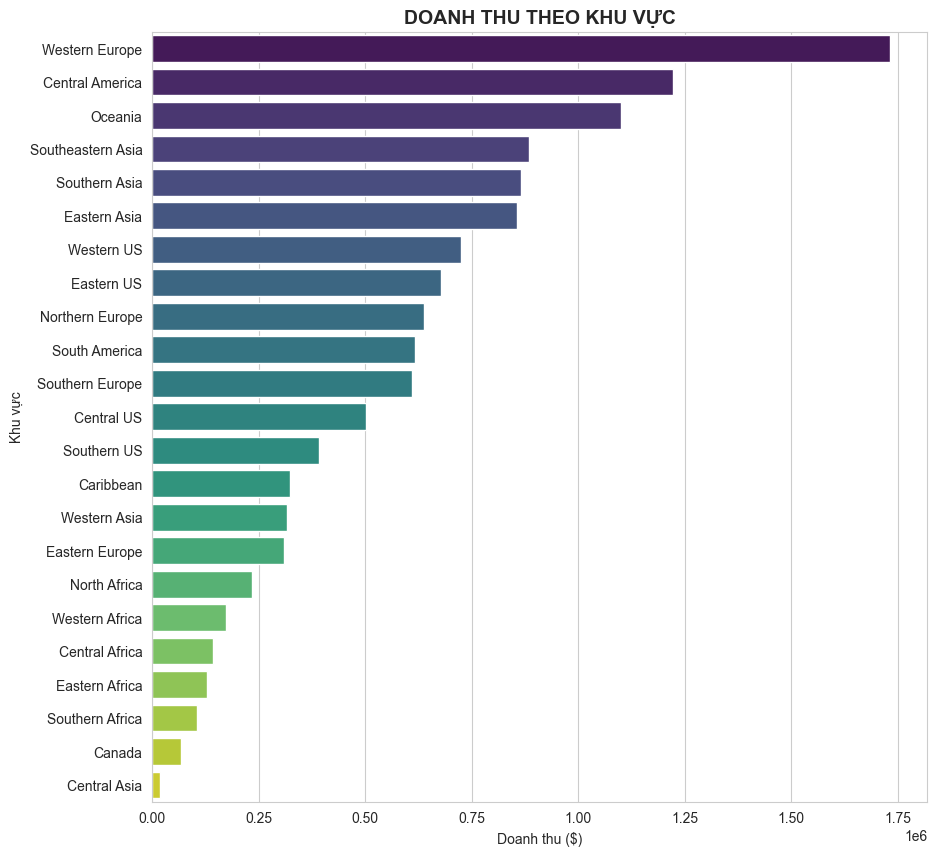

In [23]:
region_sales = od.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(data=region_sales, x='Sales', y='Region', palette='viridis', hue='Region')
plt.title('DOANH THU THEO KHU VỰC', fontsize=14, fontweight='bold')
plt.xlabel('Doanh thu ($)')
plt.ylabel('Khu vực')
plt.show()

- Khu vực Western Europe (Tây Âu) mang lại doanh thu cao nhất (gần 1.75M USD) cách khá xa 2 khu vực sau là Central American và Oceania. Cho thấy đây là những thị trường ổn định và có sức mua cao trong hệ thống
- Các khu vực thuộc châu Á đang nằm ở nhóm giữa, cho thấy cơ hội thâm nhập vào thị trường này dang ổn định và có khả năng trở thành trụ cột trong tương lai
- Sự chênh lệnh giữa nhóm đầu và nhóm cuối, điều này cho thấy sự phát triển không đồng đều giữa các thị trường trên toàn cầu
- Doanh thu thấp ở khu vực Canada nằm tại khu vực châu Mĩ cho thấy có thể có rào cản về logistic, sự cạnh tranh nội địa tại khu vực này
- Doanh thu tại Mỹ bị chia nhỏ thành nhiều vùng khiến cho thị trường này trên biểu đồ trông có vẻ thấp hơn so với thực tế tổng thể.

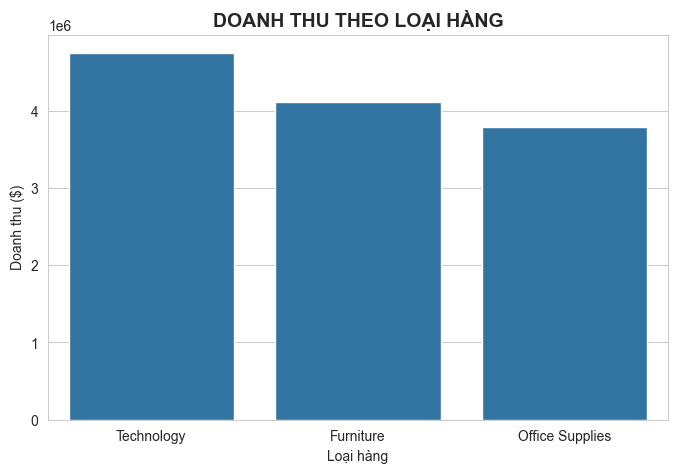

In [24]:
category_sales = od.groupby('Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x='Category', y='Sales')
plt.title('DOANH THU THEO LOẠI HÀNG', fontsize=14, fontweight='bold')
plt.xlabel('Loại hàng')
plt.ylabel('Doanh thu ($)')
plt.show()

- Doanh thu giữa 3 nhóm ngành hàng khá đồng đều (khoảng từ 3.7M - 4.7M USD)
- Hàng Technology (Công nghệ) chiếm doanh thu cao nhất phản ánh xu hướng thị trường khi các sản phẩm công nghệ thường có đơn giá cao và nhu cầu lớn trên quy mô toàn cầu.
- Ngành hàng Furniture (Nội thất) đứng thứ hai với doanh thu hơn 4.1 triệu USD. Tuy nhiên, đây là nhóm hàng đặc thù thường có chi phí vận chuyển và tỷ lệ hoàn trả cao, nên doanh thu lớn chưa chắc đã đi kèm với lợi nhuận cao nhất
- Nhóm ngành Office Supplies (Văn phòng phẩm) đứng thứ cuối nhưng đây thường là nhóm có số lượng đơn hàng lớn nhất. Các mặt hàng này giúp doanh nghiệp duy trì lượng khách hàng trung thành và lượt mua sắm lặp lại thường xuyên.

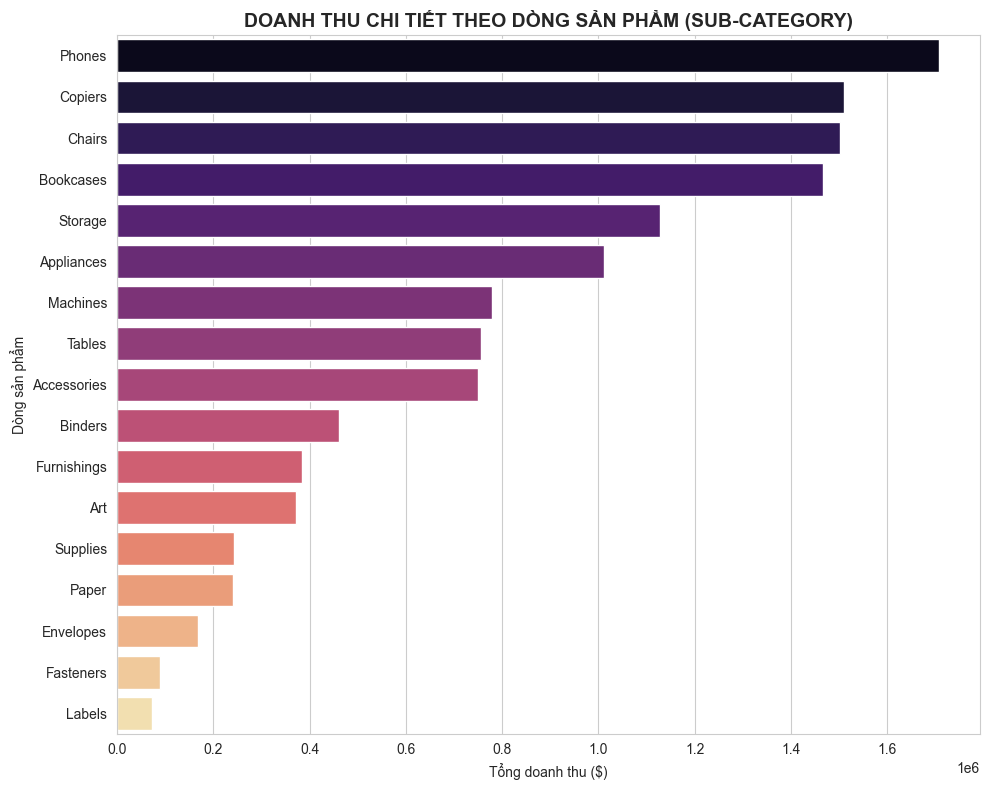

In [25]:
sub_cat_revenue = od.groupby('Sub-Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=sub_cat_revenue, x='Sales', y='Sub-Category', palette='magma',hue='Sub-Category')

plt.title('DOANH THU CHI TIẾT THEO DÒNG SẢN PHẨM (SUB-CATEGORY)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng doanh thu ($)')
plt.ylabel('Dòng sản phẩm')

plt.tight_layout()
plt.show()

- Phones và Copiers là hai dòng sản phẩm mang lại doanh thu lớn nhất (đều vượt ngưỡng 1.5 triệu USD). Điều này khẳng định nhóm hàng Technology dẫn đầu là nhờ các thiết bị điện tử có giá trị đơn hàng cao.
- Nhóm nội thất đóng góp khá đáng kể (Chairs, Bookcases, Tables) cho thấy nhu cầu về trang bị văn phòng và nhà ở cao
- Có một sự tương phản rõ rệt giữa nhóm đầu và nhóm cuối. Trong khi Phones mang về hàng triệu USD, thì các dòng như Labels (Nhãn dán) hay Fasteners (Kẹp/Ghim) có doanh thu cực thấp. Điều này cho thấy chiến lược doanh thu của công ty dựa trên các sản phẩm giá trị cao thay vì các mặt hàng phụ kiện nhỏ lẻ.

Doanh thu và lợi nhuận theo dòng sản phẩm

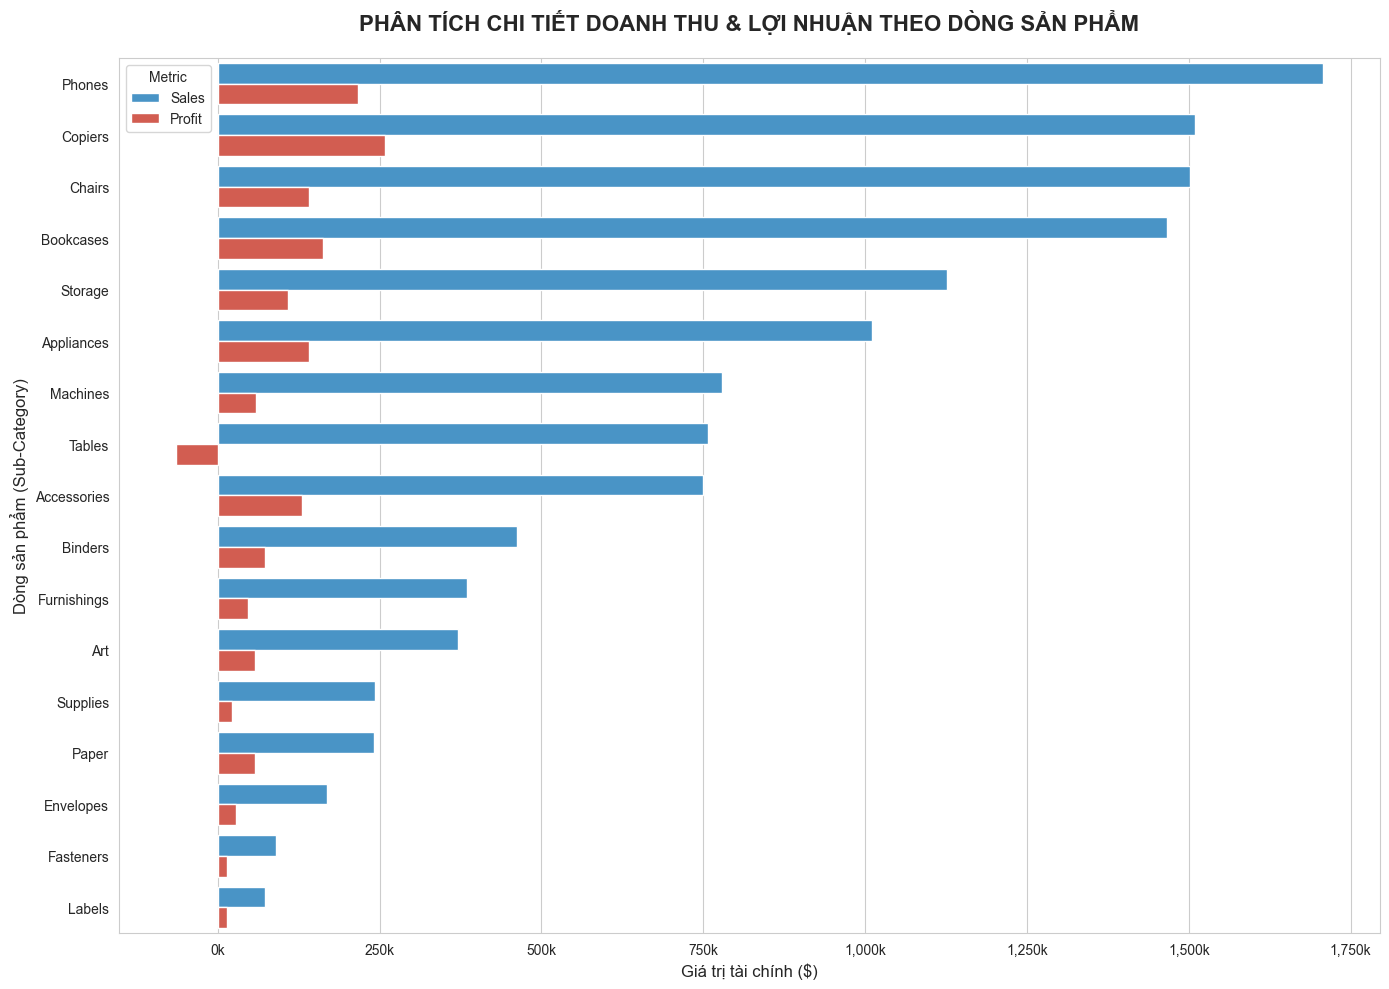


Bảng thống kê chi tiết:
Sub-Category      Sales    Profit  Profit_Margin_%
       Paper  241787.67  58111.27        24.034009
      Labels   73350.55  14988.80        20.434475
 Accessories  749237.28 129626.44        17.301120
     Copiers 1509436.51 258567.63        17.130077
   Envelopes  169217.58  28849.26        17.048619
     Binders  461870.09  72432.92        15.682531
         Art  371613.70  57829.90        15.561832
   Fasteners   89495.19  13844.08        15.469077
  Appliances 1010535.76 141562.63        14.008671
      Phones 1706824.65 216717.44        12.697112
 Furnishings  385156.15  46845.56        12.162745
   Bookcases 1466572.55 161924.37        11.041006
     Storage 1126813.78 108416.94         9.621549
      Chairs 1501682.16 140396.24         9.349265
    Supplies  242811.14  22559.04         9.290776
    Machines  779060.32  58867.70         7.556244
      Tables  757042.17 -64083.55        -8.464991


In [26]:
analysis = od.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()
analysis = analysis.sort_values('Sales', ascending=False)
melted_df = analysis.melt(id_vars='Sub-Category', var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
plot = sns.barplot(data=melted_df, x='Value', y='Sub-Category', hue='Metric', palette=['#3498db', '#e74c3c'])
plt.title('PHÂN TÍCH CHI TIẾT DOANH THU & LỢI NHUẬN THEO DÒNG SẢN PHẨM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Giá trị tài chính ($)', fontsize=12)
plt.ylabel('Dòng sản phẩm (Sub-Category)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}k".format(x/1e3)))
plt.tight_layout()
plt.show()
analysis['Profit_Margin_%'] = (analysis['Profit'] / analysis['Sales']) * 100
print("\nBảng thống kê chi tiết:")
print(analysis.sort_values('Profit_Margin_%', ascending=False)
      [['Sub-Category', 'Sales', 'Profit', 'Profit_Margin_%']]
      .to_string(index=False))

- Từ bảng thống kê có thể thấy rõ sự khác biệt giữa doanh thu và phần trăm lợi nhuận của các nhóm sản phẩm
- Một số nhóm sản phẩm như Paper và Labels có phần trăm lợi nhuận cao (24% và 20%) cho thấy khả năng kiểm soát chi phí tốt và mang lại hiệu quả kinh doanh cao. Bên cạnh đó Copier là nhóm sản phẩm nổi bật khi vừa đạt doanh thu cao và lợi nhuận cao
- Phones, Chairs, Storage là các nhóm sản phẩm có doanh thu cao nhưng phần trăm lợi nhuận lại thấp. Điều này cho thấy doanh nghiệp chưa có những chính sách giá tối ưu đối với sản phẩm này
- Đáng chú ý là nhóm Tables có phần trăm lợi nhuận âm (-8.46%) tức là đang kinh doanh thua lỗ. Đây là dấu hiệu cực kì báo động, doanh nghiệp cần xem xét lại chi phí, giá bán và chiến lược kinh doanh

So sánh mức giảm giá và tỷ suất lợi nhuận.

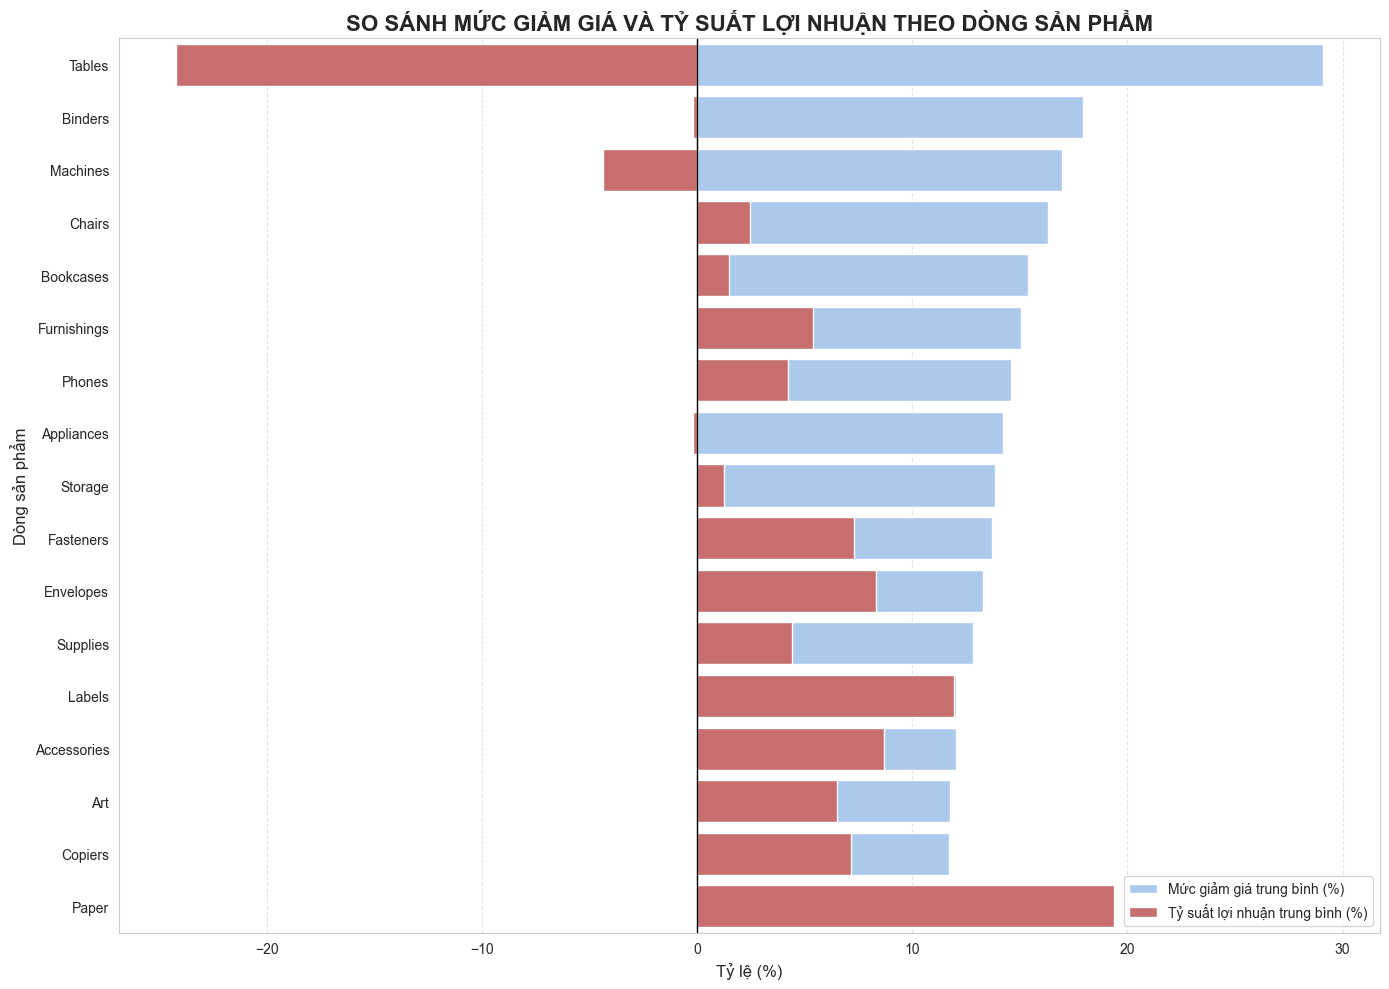


BẢNG THỐNG KÊ CHI TIẾT:
Sub-Category  Discount_%  Profit_Margin_%
      Tables   29.073171       -24.204800
     Binders   17.928409        -0.172981
    Machines   16.958277        -4.350493
      Chairs   16.311008         2.477528
   Bookcases   15.375778         1.488165
 Furnishings   15.062777         5.390950
      Phones   14.584748         4.213040
  Appliances   14.207807        -0.198507
     Storage   13.854031         1.261661
   Fasteners   13.719339         7.312973
   Envelopes   13.289066         8.292237
    Supplies   12.804321         4.412333
      Labels   12.052672        11.930966
 Accessories   12.048130         8.705600
         Art   11.757401         6.485630
     Copiers   11.714710         7.167309
       Paper   11.010882        19.371858


In [27]:
od['Profit_Margin_%'] = (od['Profit'] / od['Sales']) * 100
analysis = od.groupby('Sub-Category').agg({
    'Discount': 'mean',
    'Profit_Margin_%': 'mean'
}).reset_index()
analysis['Discount_%'] = analysis['Discount'] * 100
analysis = analysis.sort_values('Discount_%', ascending=False)
plt.figure(figsize=(14, 10))
sns.set_color_codes("pastel")
sns.barplot(x="Discount_%", y="Sub-Category", data=analysis,
            label="Mức giảm giá trung bình (%)", color="b")
sns.set_color_codes("muted")
sns.barplot(x="Profit_Margin_%", y="Sub-Category", data=analysis,
            label="Tỷ suất lợi nhuận trung bình (%)", color="r")
plt.axvline(0, color='black', lw=1)
plt.title('SO SÁNH MỨC GIẢM GIÁ VÀ TỶ SUẤT LỢI NHUẬN THEO DÒNG SẢN PHẨM', fontsize=16, fontweight='bold')
plt.xlabel('Tỷ lệ (%)', fontsize=12)
plt.ylabel('Dòng sản phẩm', fontsize=12)
plt.legend(loc="lower right", frameon=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("\nBẢNG THỐNG KÊ CHI TIẾT:")
print(analysis[['Sub-Category', 'Discount_%', 'Profit_Margin_%']].to_string(index=False))

- Từ bảng thống kê có thể thấy quan hệ nghịch giữa mức giảm giá (Discount) và tỷ suất lợi nhuận (Profit_Margin) ở nhiều nhóm sản phẩm. Các nhóm có mức discount cao thường đi kèm với lợi nhuận thấp hoặc âm
- Tables có mức discount cao nhất (~29%) nhưng lợi nhuận âm rất lớn (-24%), cho thấy việc giảm giá mạnh khiến cho doanh nghiệp bị thua lỗ
- Binders và Machines cũng có discount cao (>16%) nhưng biên lợi nhuận thấp hoặc gần bằng 0, phản ánh hiệu quả kinh doanh kém
- Chairs và Bookcases cũng có discount tương đối cao ( 15-16%) nhưng lợi nhuận của thấp (~1-2%)
- Ngược lại, Paper có mức discount thấp nhưng tỷ suất lợi nhuận là cao nhất (~19%)

-> Discount đang ảnh hưởng tiêu cực đến lợi nhuận nếu không được kiểm soát hợp lý. Một số nhóm sản phẩm đang lạm dụng chiến lược giảm giá để thúc đẩy doanh thu nhưng làm giảm hiệu quả kinh do

Biểu đồ heatmap: Lợi nhuận theo ngành hàng và khu vực

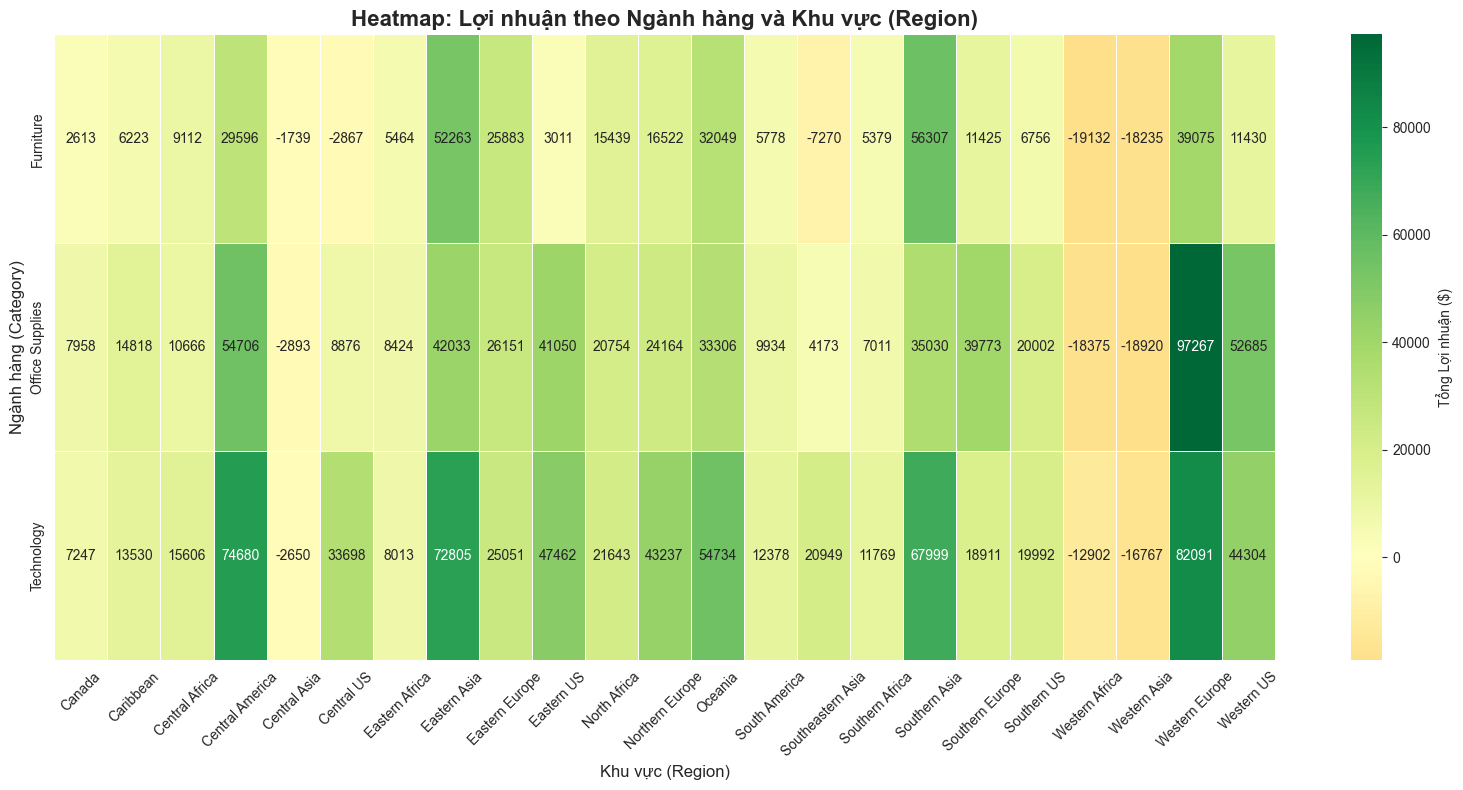


BẢNG THỐNG KÊ TỔNG LỢI NHUẬN THEO KHU VỰC:
               Region      Profit
21     Western Europe 218,433.33$
7        Eastern Asia 167,101.62$
16      Southern Asia 159,336.18$
3     Central America 158,981.81$
12            Oceania 120,089.66$
22         Western US 108,418.69$
9          Eastern US  91,522.80$
11    Northern Europe  83,923.29$
8      Eastern Europe  77,084.88$
17    Southern Europe  70,109.35$
10       North Africa  57,836.25$
18        Southern US  46,749.69$
5          Central US  39,706.44$
2      Central Africa  35,383.71$
1           Caribbean  34,571.35$
13      South America  28,090.48$
15    Southern Africa  24,158.55$
6      Eastern Africa  21,900.87$
14  Southeastern Asia  17,852.34$
0              Canada  17,817.39$
4        Central Asia  -7,282.06$
19     Western Africa -50,408.25$
20       Western Asia -53,921.70$


In [28]:
heatmap_region = od.pivot_table(index='Category',
                                columns='Region',
                                values='Profit',
                                aggfunc='sum')

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_region, annot=True, fmt=".0f", cmap='RdYlGn', center=0,
            linewidths=.5, cbar_kws={'label': 'Tổng Lợi nhuận ($)'})
plt.title('Heatmap: Lợi nhuận theo Ngành hàng và Khu vực (Region)', fontsize=16, fontweight='bold')
plt.xlabel('Khu vực (Region)', fontsize=12)
plt.ylabel('Ngành hàng (Category)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
region_profit_summary = od.groupby('Region')['Profit'].sum().reset_index()
# 3. Sắp xếp từ Lãi cao nhất đến Lỗ nặng nhất
region_profit_summary = region_profit_summary.sort_values('Profit', ascending=False)
print("\nBẢNG THỐNG KÊ TỔNG LỢI NHUẬN THEO KHU VỰC:")
print(region_profit_summary.to_string(
    formatters={'Profit': '{:,.2f}$'.format}
))

- Lợi nhuận có sự phân hóa rõ rệt giữa các khu vực và ngành hàng
- Lãi cao tập trung chủ yếu ở ngành hàng Technology và Office Supplies tại các thị trường phát triển
- Ngành hàng Furniture chịu lỗ nhiều nhất, đặc biệt tại khu vực Western Africa( -19132$) và  Western Asia(-18235$). Đây cũng là 2 khu vực lỗ nặng nhất ở cả 3 ngành hàng. Furniture thường có kích thước lớn, nặng. Nếu bán ở những vùng có cơ sở hạ tầng giao thông chưa phát triển hoặc địa hình phức tạp, phí giao hàng sẽ "ngốn" sạch lợi nhuận.
- Western Europe và Eastern Asia ( điển hình như Trung Quốc, Nhật Bản, Hàn Quốc, Anh, Pháp, Đức) và 2 khu vực có lợi nhuận cao nhất. Đây là những thị trường có nền kinh tế lớn mạnh, khách hàng sẵn sàng chi trả cho những sản phẩm có giá trị cao.

Ma trận tương quan giữa các biến số Sales, Quantity, Discount, Shipping Cost và Profit.

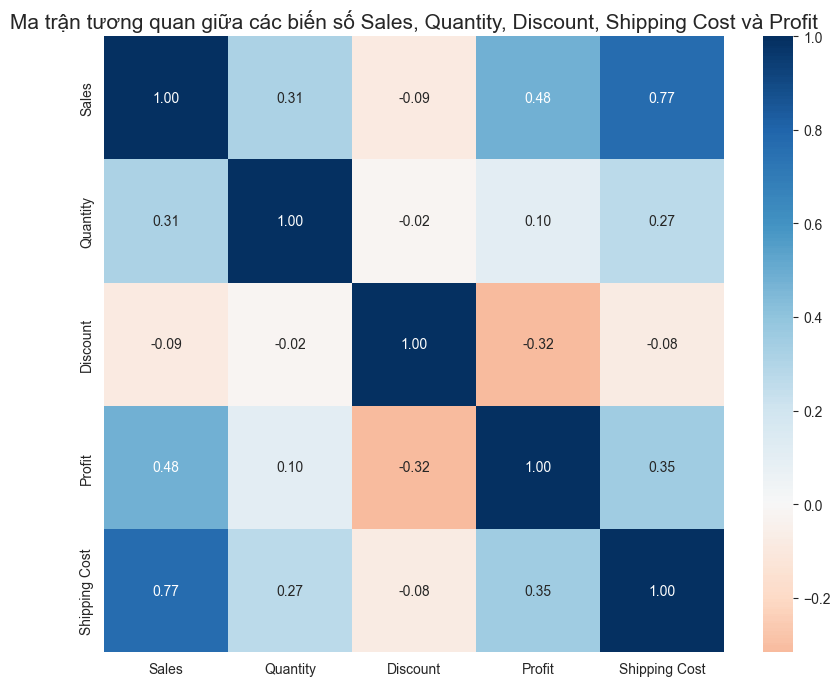

In [29]:
cols_to_analyze = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
corr_matrix = od[cols_to_analyze].corr()
%matplotlib inline
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số Sales, Quantity, Discount, Shipping Cost và Profit', fontsize=15)
plt.show()

- Hệ số tương quan giữa Discount và Profit là -0.32, thể hiện mối quan hệ nghịch biến rõ rệt. Đây là một trong những chỉ số quan trọng nhất ảnh hưởng đến hiệu quả kinh doanh. Chính sách chiết khấu đang trực tiếp làm giảm biên lợi nhuận.
- Hệ số giữa Discount và Sales là -0.09 là mức cực thấp( gần bằng 0). Thông thường, chúng ta giảm giá để tăng doanh số nhưng ở đây hệ số -0.09 cho thấy việc tăng chiết khấu không giúp doanh thu (Sales) tăng lên một cách rõ rệt, thậm chí nó còn có xu hướng làm giảm nhẹ tổng giá trị doanh thu.
- Mô hình kinh doanh phụ thuộc nặng nề vào việc kiểm soát Shipping Cost vì nó gắn liền với Sales (0.77). Bất kỳ sự tối ưu nào về vận chuyển cũng tác động lớn đến lợi nhuận
- Cần xem xét kĩ lại chế độ giảm giá. Dữ liệu cho thấy giảm giá dang phản tác dụng, không tăng được số bán, không tăng được doanh thu nhưng lại trực tiếp cắt giảm lợi nhuận.

Tỷ lệ trả hàng theo từng dòng sản phẩm

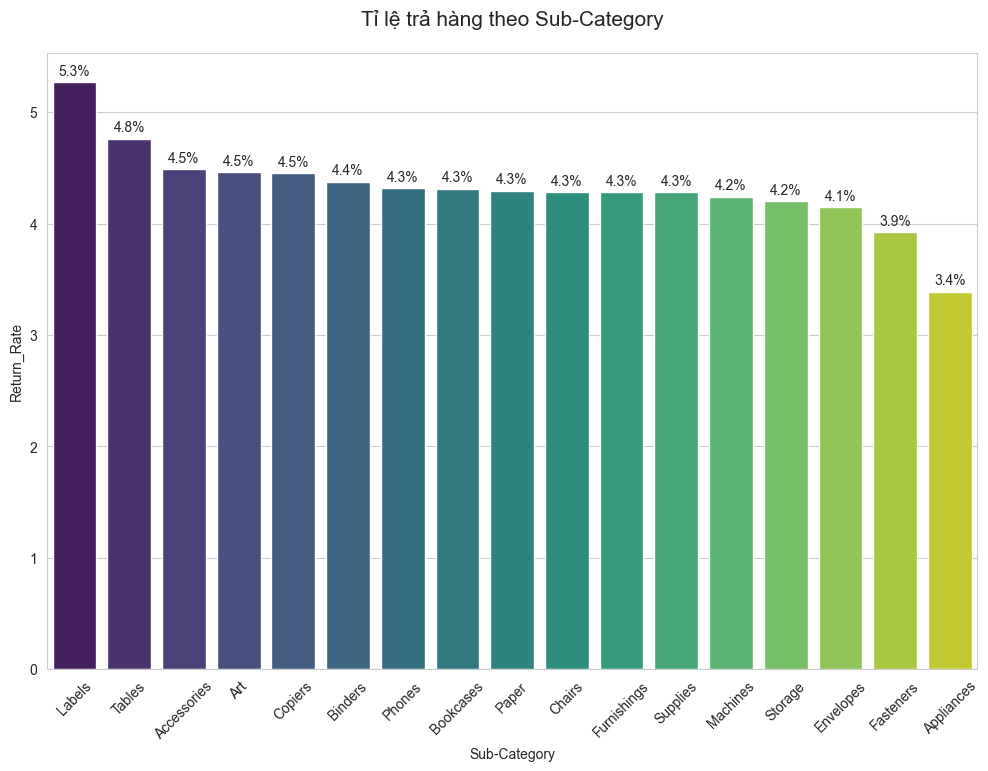

In [30]:
df_merged = pd.merge(od, rt[['Order ID', 'Returned']], on='Order ID', how='left')
df_merged['Returned'] = df_merged['Returned'].fillna('No')
stats = df_merged.groupby('Sub-Category').apply(
    lambda x: (x['Returned'] == 'Yes').sum() / len(x) * 100
).reset_index(name='Return_Rate')
stats = stats.sort_values('Return_Rate', ascending=False)
plt.figure(figsize=(12,8))
ax = sns.barplot(
    data=stats,
    x='Sub-Category',
    y='Return_Rate',
    palette='viridis',
    hue='Sub-Category',
    legend=False
)
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=3)
plt.xticks(rotation=45)
plt.title('Tỉ lệ trả hàng theo Sub-Category', fontsize=15, pad=20)
plt.show()

- Tất cả sản phẩm đều có tỉ lệ trả hàng thấp ( dưới 6%). Đây là một con số cực kỳ lý tưởng với doanh nghiệp bán lẻ toàn cầu. Chứng tỏ rằng rủi ro từ việc trả hàng không phải là nguyên nhân dẫn đến sự sụt giảm lợi nhuận ở các khu vực lỗ.

Mô hình Prophet


--- ĐANG XỬ LÝ DỰ BÁO CHO: Western Europe ---
METRICS FOR SALES IN Western Europe:
 - MAE  : 1042.06
 - RMSE : 1405.45
 - R2   : 0.2164

METRICS FOR PROFIT IN Western Europe:
 - MAE  : 268.04
 - RMSE : 416.42
 - R2   : 0.0428


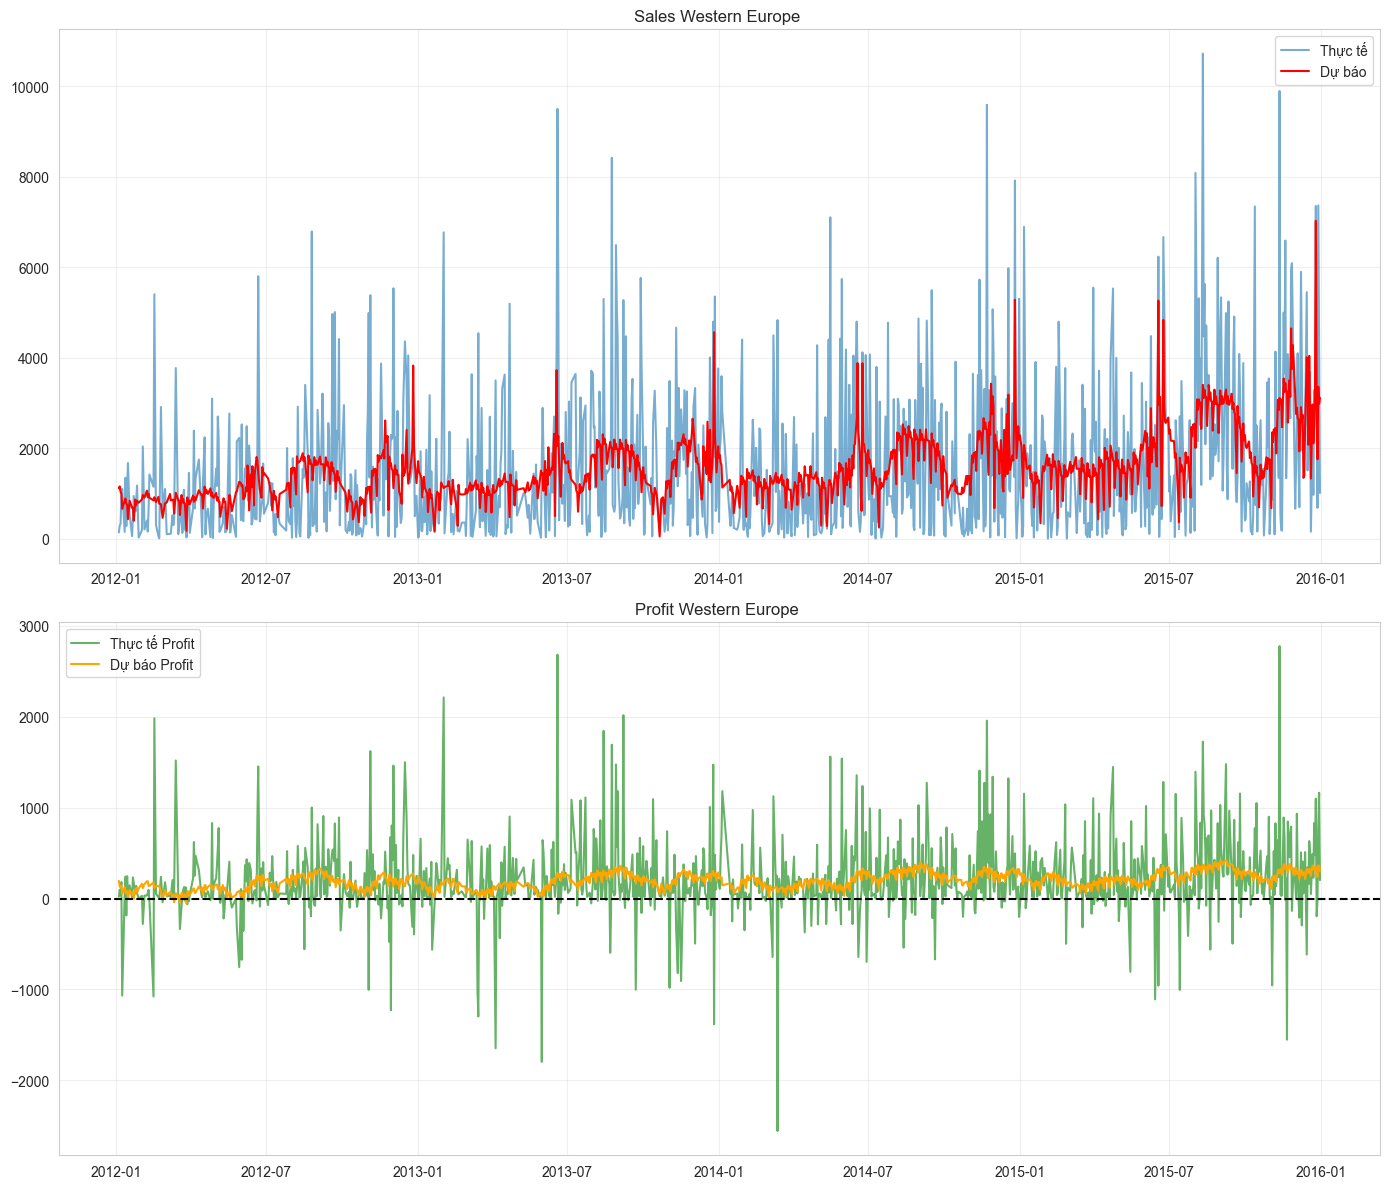


--- ĐANG XỬ LÝ DỰ BÁO CHO: Central America ---
METRICS FOR SALES IN Central America:
 - MAE  : 808.46
 - RMSE : 1113.95
 - R2   : 0.2085

METRICS FOR PROFIT IN Central America:
 - MAE  : 191.18
 - RMSE : 282.88
 - R2   : 0.0478


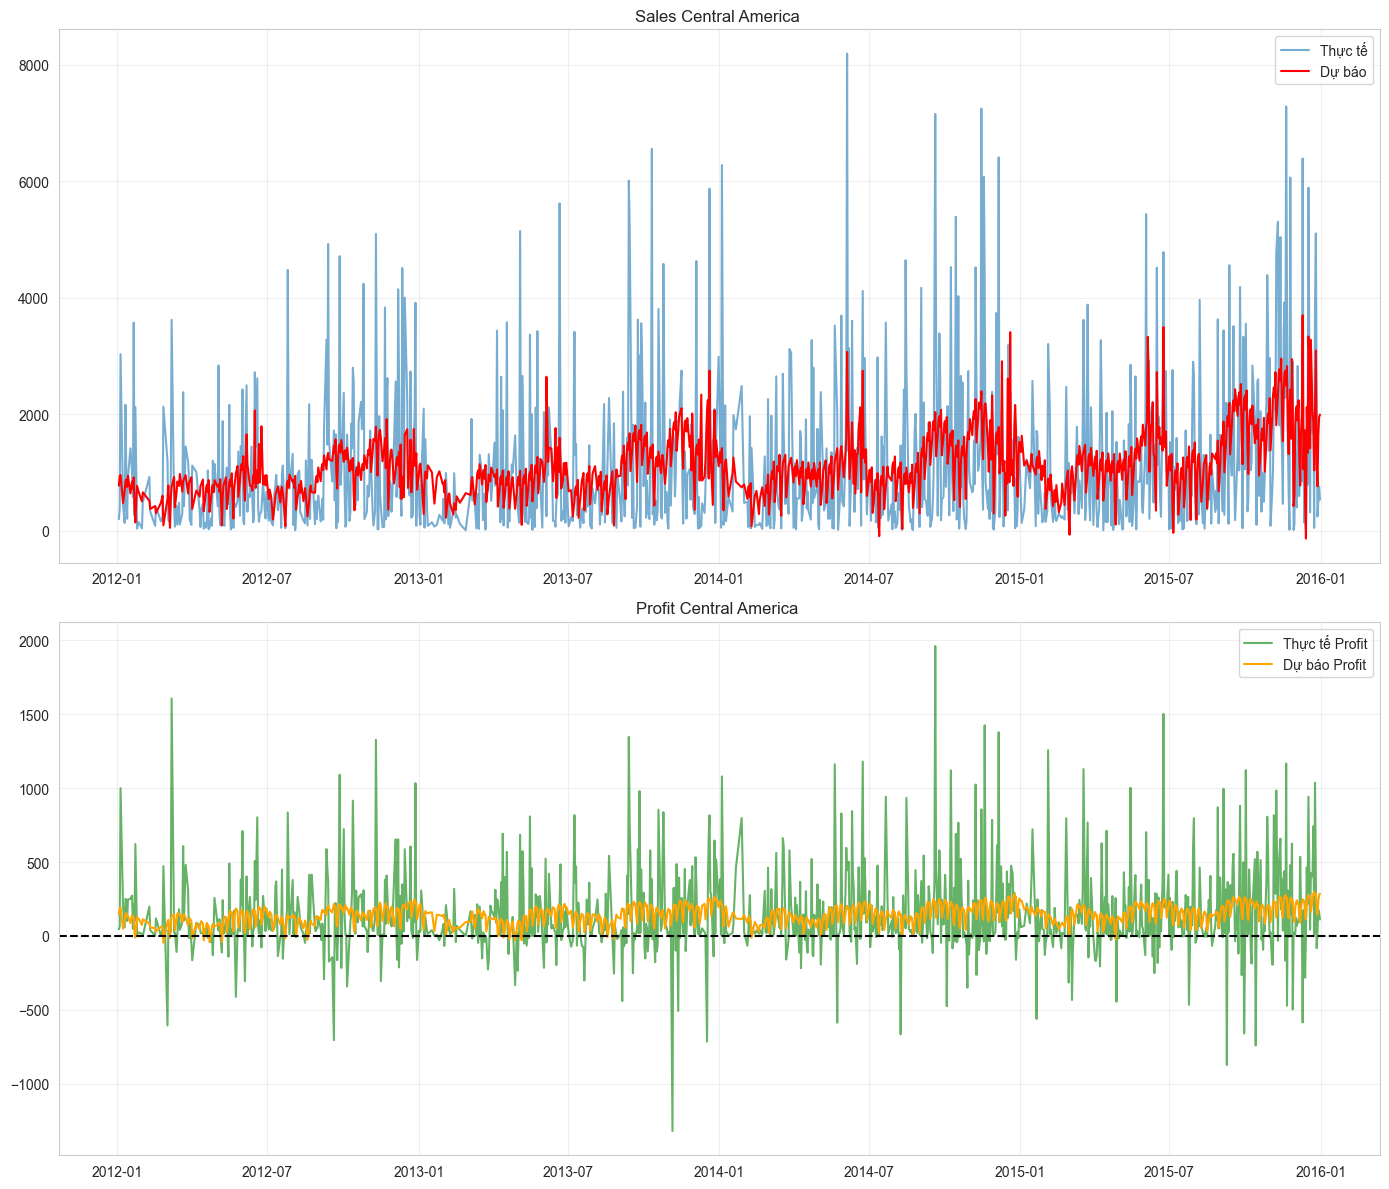


--- ĐANG XỬ LÝ DỰ BÁO CHO: Oceania ---
METRICS FOR SALES IN Oceania:
 - MAE  : 956.41
 - RMSE : 1332.33
 - R2   : 0.1432

METRICS FOR PROFIT IN Oceania:
 - MAE  : 219.93
 - RMSE : 352.54
 - R2   : 0.0369


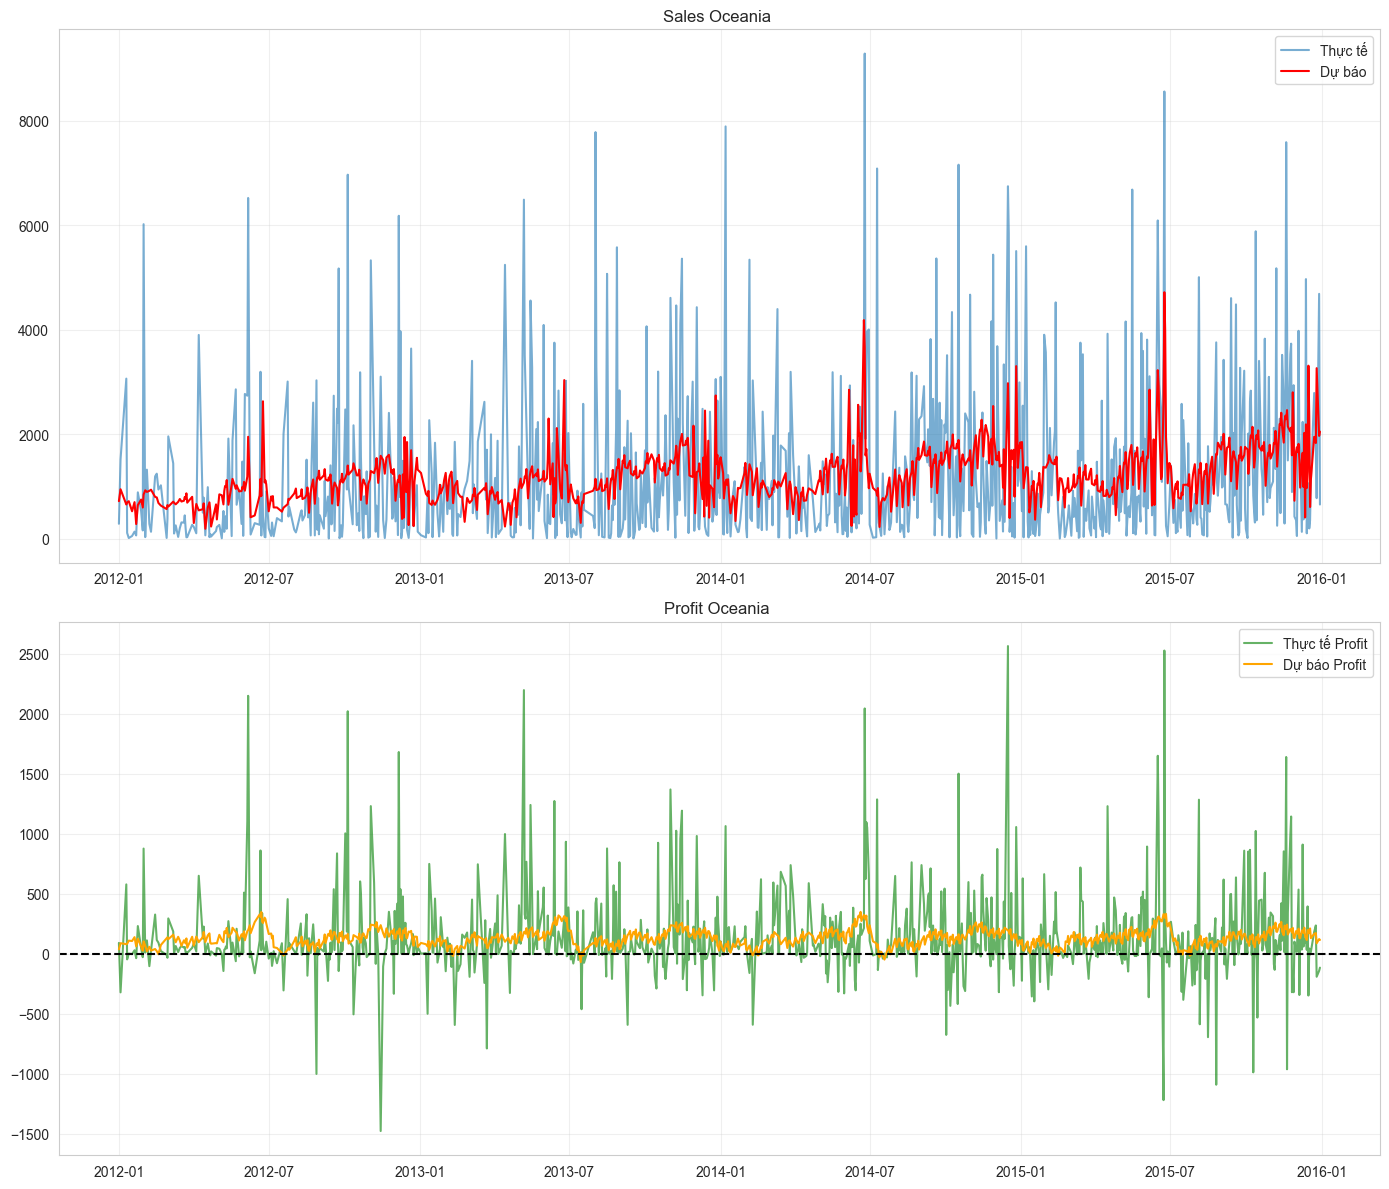

In [52]:
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
# ==================== ĐỊNH NGHĨA NGÀY LỄ ====================
mid_year_sale = pd.DataFrame({
    'holiday': 'mid_year_sale',
    'ds': pd.to_datetime(['2012-06-15', '2013-06-15', '2014-06-15', '2015-06-15']),
    'lower_window': -10, 'upper_window': 10,
})
black_friday = pd.DataFrame({
    'holiday': 'black_friday',
    'ds': pd.to_datetime(['2012-11-23', '2013-11-29', '2014-11-28', '2015-11-27']),
    'lower_window': -1,
    'upper_window': 3,
})
christmas_newyear = pd.DataFrame({
    'holiday': 'christmas_newyear',
    'ds': pd.to_datetime(['2012-12-25', '2013-12-25', '2014-12-25', '2015-12-25']),
    'lower_window': -15,
    'upper_window': 2,
})
# Gộp tất cả các ngày lễ thành danh sách tổng hợp
holidays_df = pd.concat([black_friday, christmas_newyear, mid_year_sale])
# ==================== DỰ BÁO VÀ ĐÁNH GIÁ ====================
top_regions = ['Western Europe', 'Central America', 'Oceania']

for region in top_regions:
    print(f"\n" + "="*50)
    print(f"--- ĐANG XỬ LÝ DỰ BÁO CHO: {region} ---")
    print("="*50)
    # Lọc dữ liệu theo vùng
    df_region = od[od['Region'] == region]
    # --- 1. XỬ LÝ SALES ---
    daily_sales = df_region.groupby('Order Date')['Sales'].sum().reset_index()
    daily_sales.columns = ['ds', 'y']
    # Khởi tạo và huấn luyện mô hình
    model_sales = Prophet(
        holidays=holidays_df,
        yearly_seasonality=True, # Tìm quy luật theo năm
        weekly_seasonality=True, # Tìm quy luật theo mùa
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.1
    )
    model_sales.fit(daily_sales)
    # Dự báo tương tai
    future_sales = model_sales.make_future_dataframe(periods=365)
    forecast_sales = model_sales.predict(future_sales)
    # --- 2. XỬ LÝ PROFIT ---
    daily_profit = df_region.groupby('Order Date')['Profit'].sum().reset_index()
    daily_profit.columns = ['ds', 'y']
    model_profit = Prophet(yearly_seasonality=True)
    model_profit.fit(daily_profit)
    future_profit = model_profit.make_future_dataframe(periods=365)
    forecast_profit = model_profit.predict(future_profit)
    # ==================== ĐÁNH GIÁ CHI TIẾT ====================
    # --- Đánh giá Sales ---
    # Trộn dữ liệu thực tế và dữ liệu dự báo lại với nhau để so sánh
    perf_sales = pd.merge(daily_sales[['ds', 'y']], forecast_sales[['ds', 'yhat']], on='ds')
    # Tính các chỉ số sai số
    mae_s = mean_absolute_error(perf_sales['y'], perf_sales['yhat'])
    rmse_s = np.sqrt(mean_squared_error(perf_sales['y'], perf_sales['yhat']))
    r2_s = r2_score(perf_sales['y'], perf_sales['yhat'])
    print(f"METRICS FOR SALES IN {region}:")
    print(f" - MAE  : {mae_s:.2f}")
    print(f" - RMSE : {rmse_s:.2f}")
    print(f" - R2   : {r2_s:.4f}")
    # --- Đánh giá Profit ---
    # Trộn dữ liệu thực tế và dữ liệu dự báo lại với nhau để so sánh
    perf_profit = pd.merge(daily_profit[['ds', 'y']], forecast_profit[['ds', 'yhat']], on='ds')
    # Tính các chỉ số sai số
    mae_p = mean_absolute_error(perf_profit['y'], perf_profit['yhat'])
    rmse_p = np.sqrt(mean_squared_error(perf_profit['y'], perf_profit['yhat']))
    r2_p = r2_score(perf_profit['y'], perf_profit['yhat'])
    print(f"\nMETRICS FOR PROFIT IN {region}:")
    print(f" - MAE  : {mae_p:.2f}")
    print(f" - RMSE : {rmse_p:.2f}")
    print(f" - R2   : {r2_p:.4f}")
    # ==================== VẼ BIỂU ĐỒ ====================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    # Đồ thị Sales
    ax1.plot(perf_sales['ds'], perf_sales['y'], label='Thực tế', alpha=0.6)
    ax1.plot(perf_sales['ds'], perf_sales['yhat'], label='Dự báo', color='red')
    ax1.set_title(f"Sales {region} ")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    # Đồ thị Profit
    ax2.plot(perf_profit['ds'], perf_profit['y'], label='Thực tế Profit', alpha=0.6, color='green')
    ax2.plot(perf_profit['ds'], perf_profit['yhat'], label='Dự báo Profit', color='orange')
    ax2.axhline(y=0, color='black', linestyle='--')
    ax2.set_title(f"Profit {region} ")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Nguyên nhân không làm dự báo doanh thu và lợi nhuận trên toàn cầu
 - Mỗi khu vực địa lý có đặc thù kinh tế, văn hóa và mùa vụ khác nhau. Ví dụ,ở Châu Âu, Châu Mỹ có mùa mua sắm cao điểm như Giáng Sinh khác với khu vực khác. Nếu dự báo tổng thì các đỉnh và đáy sẽ san phằng nhau, làm mô hình Prophet mất đi tính chính xác của thành phần mùa vụ. Việc tách riêng 3 khu vực có doanh thu cao nhất giúp mô hình học được tín hiệu sạch nhất và đặc trưng nhất.
  - Trong hệ thống bán lẻ Global Superstore, 3 khu vực Western Europe, Central America và Oceania chiếm tỷ trọng doanh thu lớn nhất. Theo nguyên lý Pareto, việc dự báo chính xác 20% các thị trường trọng điểm sẽ mang lại 80% giá trị cho việc lập kế hoạch vận hành và dòng tiền. Thay vì dự báo dàn trải cho các khu vực có dữ liệu thưa thớt (sparse data) dễ gây sai số lớn, t tập trung nguồn lực vào những nơi mang lại giá trị thực tế nhất cho doanh nghiệp."
  - Qua phân tích, ta nhận thấy đây là những vùng có doanh thu cao nhưng biên lợi nhuận lại có sự biến động trái ngược nhau. Việc tập trung vào 3 vùng tiêu biểu này giúp ta làm rõ được vấn đề: Tại sao doanh thu dự báo tăng nhưng lợi nhuận thực tế lại bất ổn?


Western Europe
- R^2 = 0.1750 của Sales: Mô hình Prophet hiện tại chỉ giải thích được 17.5% sự biến động của doanh thu hàng ngày đây là mức thấp. Do dữ liệu bán lẻ theo ngày thường khá biến động.
- R^2 = 0.0428 của Profit: Mô hình chỉ giải thích được 4.28% biến động lợi nhuận cho thấy Prophet gần như không dự báo được lợi nhuận theo ngày. Lợi nhuận phụ thuộc rất nhiều vào các biến số như Discount, Shipping Cost.

Central America
- MAE của Sales là 825.07 đây là vùng có sai số MAE thấp nhất trong 3 khu vực. Tuy nhiên R^2 ~ 16% chứng tỏ dữ liệu hàng ngày vẫn bị nhiễu cao và chưa tối ưu khi dự báo thuần thời gian
- Về Profit tuy sai số tiền mặt thấp nhưng R^2 gần bằng 0. Điều này cho thấy Prophet gần như không thể dự báo được chính xác lợi nhuận

Oceania
- Về Sales: MAE = 980.65 và R^2 = 0.0901. Đây là khu vực có độ chính xác thấp nhất trong 3 vùng. Hệ số R^2 quá thấp cho thấy Prophet gần như không thể nắm bắt được quy luật biến động của thị trường.

=> Việc sử dụng mô hình Prophet để dự báo doanh thu và lợi nhuận trên 3 thị trường trọng điểm là một kết quả quan trọng nhưng còn nhiều hạn chế vì các chỉ số MAE, RMSE đều ở mức khá cao trong khi R^2 rất thấp ở cả 3 thị trường và RMSE luôn lớn hơn đáng kể so với MAE. Kết quả này chứng minh rằng dữ liệu bán lẻ theo ngày bị nhiễu quá mạnh và các yếu tố thời gian thuần túy không đủ để giải thích sự biến động phức tạp của thị trường. Do đó cần chuyển sang mô hình học máy mạnh hơn là XGBoost. Với khả năng xử lý các biến phụ trợ phi tuyến tính như Discount, Category, Shipping Cost, XGBoost được kỳ vọng sẽ khắc phục cá lỗ hổng của Prophet, giúp nâng cao độ chính xác.

Hai mô hình này khác phạm vi nhưng bổ trợ cho nhau. Prophet giúp ta khẳng định đặc điểm của dữ liệu có tính mùa vụ nhưng bị nhiễu mạnh, còn XGBoost giúp ta đưa ra giải pháp tận dụng những đặc trưng đơn hàng để vượt qua sự nhiễu đó.

Mô hình XGBoost

XGBOOST RESULTS:
R2 Score : 0.4457
WAPE     : 48.51%


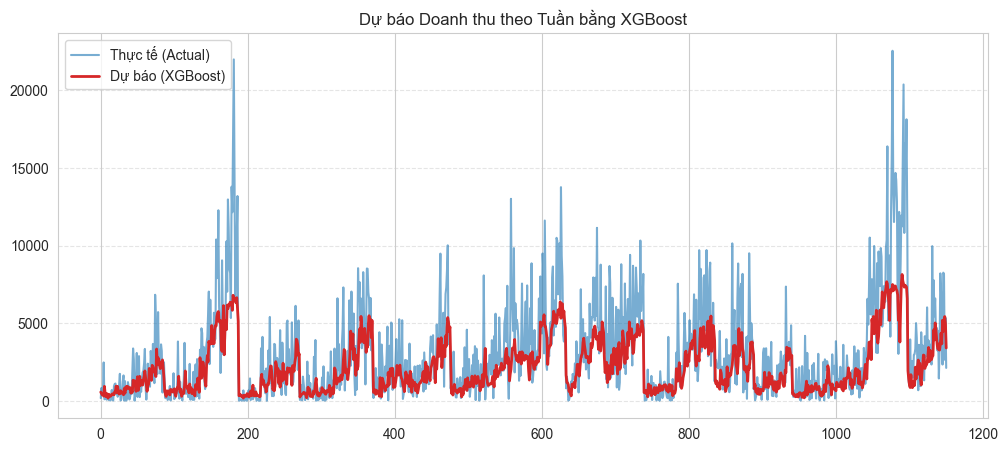

In [51]:
# BƯỚC 1: TIỀN XỬ LÝ & GỘP DỮ LIỆU
train_cutoff = '2015-01-01' # Điểm mốc thời gian chia để huấn luyện và test
sales_limit = od[od['Order Date'] < train_cutoff]['Sales'].quantile(0.95)
od['Sales_Cleaned'] = od['Sales'].clip(upper=sales_limit) # Xử lý outliers

# Gộp dữ liệu theo Tuần (W) và Vùng (Region)
data_input = od.set_index('Order Date').groupby([
    pd.Grouper(freq='W'), 'Region'
]).agg({
    'Sales_Cleaned': 'sum',
    'Discount': 'mean',
    'Quantity': 'sum'
}).reset_index()
data_input.columns = ['ds', 'region', 'y', 'discount', 'quantity'] # Đổi tên cột

# BƯỚC 2: FEATURE ENGINEERING (HÀM XỬ LÝ ĐẶC TRƯNG)
def xgb_features_full(df):
    df = df.copy().sort_values(['region', 'ds'])

    # Biến thời gian cơ bản
    df['week'] = df['ds'].dt.isocalendar().week.astype(int)
    df['month'] = df['ds'].dt.month
    df['year'] = df['ds'].dt.year

    # Biến lượng giác: Sin/Cos biến thời gian thẳng thành vòng tròn
    df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

    # Dùng Log để: Nén các giá trị doanh thu quá lớn lại, đưa dữ liệu về dạng
    # phân phối chuẩn để mô hình học ổn định hơn, chuyển mục tiêu học về sai số %
    # thay vì sai số là số tiền tuyệt đối. Log1p xử lý doanh thu bằng 0 vì log(0)
    # không xác định.
    df['y_log'] = np.log1p(df['y'])

    # Tạo biến Lag (Trễ)
    # shift(l): đẩy dữ liệu lùi lại tránh bị leak
    for l in [1, 2, 4, 52]:
        df[f'lag_{l}'] = df.groupby('region')['y_log'].shift(l)

    # Rolling Mean: san phẳng nhiễu
    # Lấy trung bình doanh số 4 tuần gần nhất để xem sức mua chung đang tăng hay giảm
    df['roll_mean_4'] = df.groupby('region')['lag_1'].transform(lambda x: x.rolling(4).mean())

    # One-hot Encoding cho biến Region
    df = pd.get_dummies(df, columns=['region'], drop_first=True)

    return df.dropna()

# Gọi hàm để tạo dữ liệu cuối cùng
data_xgb_final = xgb_features_full(data_input)
# BƯỚC 3: CHIA DỮ LIỆU & HUẤN LUYỆN
train_x = data_xgb_final[data_xgb_final['ds'] < train_cutoff]
test_x = data_xgb_final[data_xgb_final['ds'] >= train_cutoff]
# Loại bỏ các cột không dùng làm đầu vào huấn luyện
cols_to_drop = ['ds', 'y', 'y_log', 'quantity', 'discount']
features_list = [c for c in train_x.columns if c not in cols_to_drop]
# Cấu hình XGBoost với Regularization
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    reg_lambda=15, # Phanh L2
    reg_alpha=5,   # Phanh L1
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

model_xgb.fit(
    train_x[features_list], train_x['y_log'],
    eval_set=[(test_x[features_list], np.log1p(test_x['y']))],
    verbose=False
)
# BƯỚC 4: DỰ BÁO & ĐÁNH GIÁ
y_pred_xgb = np.expm1(model_xgb.predict(test_x[features_list]))
y_true = test_x['y']

r2 = r2_score(y_true, y_pred_xgb)
wape = (np.abs(y_true - y_pred_xgb).sum() / y_true.sum()) * 100

print(f"XGBOOST RESULTS:")
print(f"R2 Score : {r2:.4f}")
print(f"WAPE     : {wape:.2f}%")
# BƯỚC 5: VẼ BIỂU ĐỒ
plt.figure(figsize=(12, 5))
plt.plot(y_true.values, label='Thực tế (Actual)', color='tab:blue', alpha=0.6)
plt.plot(y_pred_xgb, label='Dự báo (XGBoost)', color='tab:red', linewidth=2)
plt.title('Dự báo Doanh thu theo Tuần bằng XGBoost')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

RF R2 Score: 0.4604


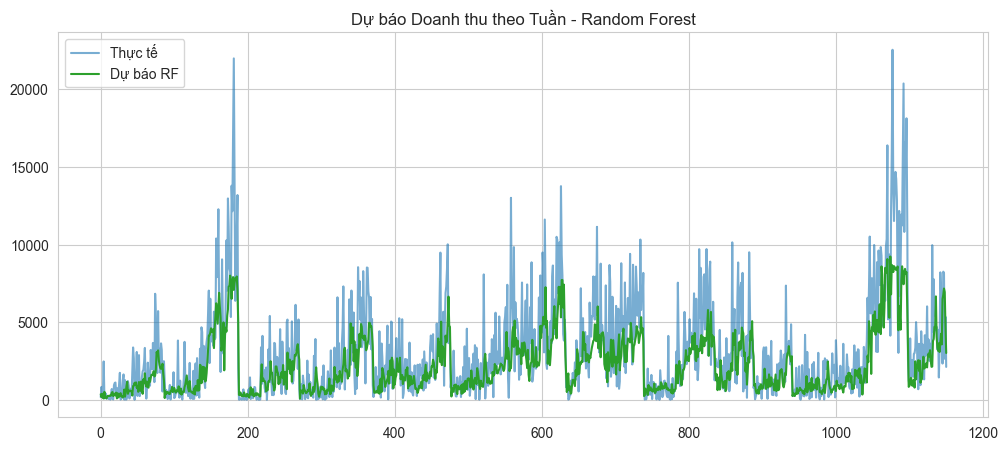

In [47]:
# --- Bước 1: Tiền xử lý & Chống Leakage ---
od['Order Date'] = pd.to_datetime(od['Order Date'])
# Tính ngưỡng 95% chỉ trên dữ liệu trước 2015
sales_limit = od[od['Order Date'] < '2015-01-01']['Sales'].quantile(0.95)
od['Sales_Cleaned'] = od['Sales'].clip(upper=sales_limit)

# Gộp theo Tuần và Vùng
data_rf = od.set_index('Order Date').groupby([pd.Grouper(freq='W'), 'Region']).agg({
    'Sales_Cleaned': 'sum', 'Discount': 'mean', 'Quantity': 'sum'
}).reset_index()
data_rf.columns = ['ds', 'region', 'y', 'discount', 'quantity']

# --- Bước 2: Feature Engineering ---
def rf_features(df):
    df = df.copy().sort_values(['region', 'ds'])
    df['week'] = df['ds'].dt.isocalendar().week.astype(int)
    df['month'] = df['ds'].dt.month
    df['year'] = df['ds'].dt.year

    # Lag & Rolling (Tuyệt đối dùng shift để chống leak)
    for l in [1, 4, 52]:
        df[f'lag_{l}'] = df.groupby('region')['y'].shift(l)
    df['roll_mean_4'] = df.groupby('region')['lag_1'].transform(lambda x: x.rolling(4).mean())

    le = LabelEncoder()
    df['region_enc'] = le.fit_transform(df['region'])
    return df.dropna()

data_rf_final = rf_features(data_rf)
train = data_rf_final[data_rf_final['ds'] < '2015-01-01']
test = data_rf_final[data_rf_final['ds'] >= '2015-01-01']

features = ['region_enc', 'week', 'month', 'year', 'lag_1', 'lag_4', 'lag_52', 'roll_mean_4']

# --- Bước 3: Huấn luyện & Vẽ biểu đồ ---
rf_model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(train[features], np.log1p(train['y']))

y_pred_rf = np.expm1(rf_model.predict(test[features]))
print(f"RF R2 Score: {r2_score(test['y'], y_pred_rf):.4f}")

plt.figure(figsize=(12, 5))
plt.plot(test['y'].values, label='Thực tế', color='tab:blue', alpha=0.6)
plt.plot(y_pred_rf, label='Dự báo RF', color='tab:green')
plt.title('Dự báo Doanh thu theo Tuần - Random Forest')
plt.legend()
plt.show()